Name:Sat Naing Tun, ID:st125333

Modify AlexNet on CIFAR 10 and train using Keras. Please submit notebook and pdf for this assignment.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_images = train_images.astype("float32") / 255
test_images = test_images.astype("float32") / 255
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [3]:
input_shape=(32, 32, 3)


alexnet = tf.keras.Sequential([
    # Layer 1: Conv1 (no padding)
    layers.Conv2D(filters=96, kernel_size=3, strides=1, padding='valid', activation='relu', input_shape=input_shape),
    layers.MaxPooling2D(pool_size=3, strides=2),

    # Layer 2: Conv2 (padding=2 → 'same')
    layers.Conv2D(filters=256, kernel_size=5, strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=3, strides=2),

    # Layer 3: Conv3
    layers.Conv2D(filters=384, kernel_size=3, strides=1, padding='same', activation='relu'),

    # Layer 4: Conv4
    layers.Conv2D(filters=384, kernel_size=3, strides=1, padding='same', activation='relu'),

    # Layer 5: Conv5
    layers.Conv2D(filters=256, kernel_size=3, strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=3, strides=2),

    # Flatten and Fully Connected Layers
    layers.Flatten(),
    layers.Dense(units=4096, activation='relu'),
    layers.Dropout(rate=0.5),
    layers.Dense(units=4096, activation='relu'),
    layers.Dropout(rate=0.5),
    layers.Dense(units=1000, activation='softmax')
])

alexnet.summary()











/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,791,656 (109.83 MB)

 Trainable params: 28,791,656 (109.83 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
alexnet.compile(optimizer="SGD",
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

In [5]:
alexnet.fit(train_images, train_labels, epochs=15, batch_size=64, validation_split=0.2)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.0902 - loss: 3.7335 - val_accuracy: 0.1279 - val_loss: 2.3311
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.1270 - loss: 2.3135 - val_accuracy: 0.2089 - val_loss: 2.1252
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.2079 - loss: 2.0851 - val_accuracy: 0.2797 - val_loss: 1.9184
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.2527 - loss: 1.9472 - val_accuracy: 0.3321 - val_loss: 1.7606
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.3227 - loss: 1.8110 - val_accuracy: 0.3538 - val_loss: 1.7351
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.3698 - loss: 1.6870 - val_accuracy: 0.3593 - val_loss: 1.7127
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4111 - loss: 1.5875 - val_accuracy: 0.4565 - val_loss: 1.4825
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4569 - loss: 1.4765 - 

In [6]:
test_loss, test_acc = alexnet.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal test accuracy: {test_acc:.4f}")

313/313 - 3s - 10ms/step - accuracy: 0.6546 - loss: 0.9729

Final test accuracy: 0.6546


In [7]:
import matplotlib.pyplot as plt
import numpy as np

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


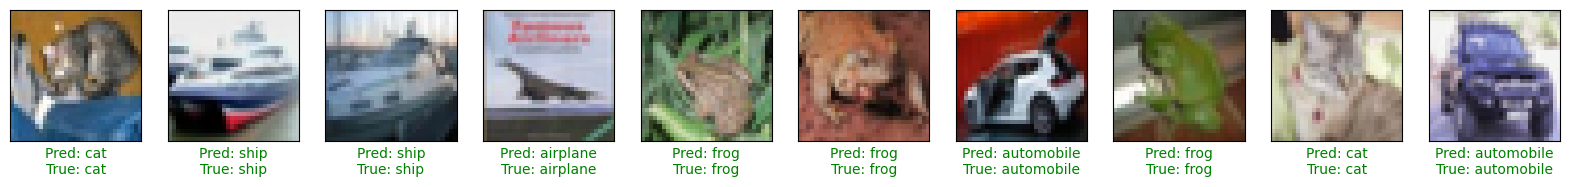

313/313 - 2s - 6ms/step - accuracy: 0.6546 - loss: 0.9729

Final test accuracy: 0.6546


In [9]:
(train_images_ori, train_labels_ori), (test_images_ori, test_labels_ori) = cifar10.load_data()
test_digits = test_images[0:10]
predictions = alexnet.predict(test_digits)
plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(test_images_ori[i])
    plt.xticks([])
    plt.yticks([])
    predicted_label_index = np.argmax(predictions[i])
    true_label_index = test_labels[i][0]
    predicted_class = class_names[predicted_label_index]
    true_class = class_names[true_label_index]
    color = 'green' if predicted_label_index == true_label_index else 'red'
    plt.xlabel(f"Pred: {predicted_class}\nTrue: {true_class}", color=color)
plt.show()
test_loss, test_acc = alexnet.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal test accuracy: {test_acc:.4f}")